In [1]:
#1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
#from sklearn.naive_bayes import ComplementNB
from sklearn.naive_bayes import BernoulliNB
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score,LeaveOneOut
from sklearn.model_selection import KFold
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report


In [3]:
data = pd.read_csv('F:/Dataset/Bank_Personal_Loan_Modelling(1).csv') 
data 

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1/90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0/40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0/30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0/50,2,0,0,0,0,1,0


In [4]:
df=pd.DataFrame(data)

In [5]:
df1=pd.DataFrame(df)

In [6]:
df1['CCAvg'] = df1['CCAvg'].apply(lambda x: x.replace('/', '.')).astype(float)
df1

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [7]:
df1['Experience'] = df1['Experience'].abs()

In [8]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.134600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.415189,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,0.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [9]:
print("show missing value :",df.isnull().sum()) 

show missing value : ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


In [10]:
df1.drop(columns="ID",inplace=True)
df1

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [11]:
incom2=df1["Income"]**2
ccavg2=df1["CCAvg"]**2
Education2=df1["Education"]**2
Mortgage2=df1["Mortgage"]**2

In [12]:
df1.insert(13,"incom2",incom2)
df1.insert(14,"ccavg2",ccavg2)
df1.insert(15,"Mortgage2",Mortgage2)
df1.insert(16,"Education2",Education2)
df1

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,incom2,ccavg2,Mortgage2,Education2
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,2401,2.56,0,1
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,1156,2.25,0,1
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,121,1.00,0,1
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,10000,7.29,0,4
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,2025,1.00,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,0,1,0,1600,3.61,0,9
4996,30,4,15,92037,4,0.4,1,85,0,0,0,1,0,225,0.16,7225,1
4997,63,39,24,93023,2,0.3,3,0,0,0,0,0,0,576,0.09,0,9
4998,65,40,49,90034,3,0.5,2,0,0,0,0,1,0,2401,0.25,0,4


In [13]:
df1["incom_edu"]=df1["Education"]*df1["Income"]
df1["incom_ccav"]=df1["Income"]*df1["CCAvg"]
df1["inco_mort"]=df1["Mortgage"]*df1["Income"]
df1["incom_famil"]=df1["Income"]*df1["Family"]
df1["inco_cd"]=df1["CD Account"]*df1["Income"]
df1

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,...,CreditCard,incom2,ccavg2,Mortgage2,Education2,incom_edu,incom_ccav,inco_mort,incom_famil,inco_cd
0,25,1,49,91107,4,1.6,1,0,0,1,...,0,2401,2.56,0,1,49,78.4,0,196,0
1,45,19,34,90089,3,1.5,1,0,0,1,...,0,1156,2.25,0,1,34,51.0,0,102,0
2,39,15,11,94720,1,1.0,1,0,0,0,...,0,121,1.00,0,1,11,11.0,0,11,0
3,35,9,100,94112,1,2.7,2,0,0,0,...,0,10000,7.29,0,4,200,270.0,0,100,0
4,35,8,45,91330,4,1.0,2,0,0,0,...,1,2025,1.00,0,4,90,45.0,0,180,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,...,0,1600,3.61,0,9,120,76.0,0,40,0
4996,30,4,15,92037,4,0.4,1,85,0,0,...,0,225,0.16,7225,1,15,6.0,1275,60,0
4997,63,39,24,93023,2,0.3,3,0,0,0,...,0,576,0.09,0,9,72,7.2,0,48,0
4998,65,40,49,90034,3,0.5,2,0,0,0,...,0,2401,0.25,0,4,98,24.5,0,147,0


In [14]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
 13  incom2              5000 non-null   int64  
 14  ccavg2              5000 non-null   float64
 15  Mortgage2           5000 non-null   int64  
 16  Educat

In [15]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
norm = scaler.fit_transform(df1.iloc[:,[0,2,3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,19,20,21]])
norm_df1 = pd.DataFrame(norm,columns = ["inco_cd","inco_mort","incom_ccav","incom_edu","incom_famil",
                                        "CCAvg2","Income2","Education2","Mortgage2","Age",
                                        "Income","ZIP Code","Family","CCAvg","Education","Mortgage",
                                        "Securities Account","CD Account","Online","CreditCard"])
norm_df1["Personal Loan"] = df1["Personal Loan"]
norm_df1.head(5)

,inco_cd,inco_mort,incom_ccav,incom_edu,incom_famil,CCAvg2,Income2,Education2,Mortgage2,Age,...,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
0,0.045455,0.189815,0.936527,1.000000,0.16,0.0,0.0,1.0,0.0,0.0,...,0.046636,0.0256,0.0,0.000,0.068220,0.038621,0.0,0.243523,0.0,0
1,0.500000,0.120370,0.924872,0.666667,0.15,0.0,0.0,1.0,0.0,0.0,...,0.021791,0.0225,0.0,0.000,0.043261,0.025123,0.0,0.121762,0.0,0
2,0.363636,0.013889,0.977892,0.000000,0.10,0.0,0.0,0.0,0.0,0.0,...,0.001137,0.0100,0.0,0.000,0.004992,0.005419,0.0,0.003886,0.0,0
3,0.272727,0.425926,0.970931,0.000000,0.27,0.5,0.0,0.0,0.0,0.0,...,0.198276,0.0729,0.0,0.375,0.319468,0.133005,0.0,0.119171,0.0,0
4,0.272727,0.171296,0.939080,1.000000,0.10,0.5,0.0,0.0,0.0,0.0,...,0.039132,0.0100,0.0,0.375,0.136439,0.022167,0.0,0.222798,0.0,0


In [16]:
norm_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   inco_cd             5000 non-null   float64
 1   inco_mort           5000 non-null   float64
 2   incom_ccav          5000 non-null   float64
 3   incom_edu           5000 non-null   float64
 4   incom_famil         5000 non-null   float64
 5   CCAvg2              5000 non-null   float64
 6   Income2             5000 non-null   float64
 7   Education2          5000 non-null   float64
 8   Mortgage2           5000 non-null   float64
 9   Age                 5000 non-null   float64
 10  Income              5000 non-null   float64
 11  ZIP Code            5000 non-null   float64
 12  Family              5000 non-null   float64
 13  CCAvg               5000 non-null   float64
 14  Education           5000 non-null   float64
 15  Mortgage            5000 non-null   float64
 16  Securi

In [17]:
x=norm_df1.iloc[:,:20].values
y=norm_df1["Personal Loan"].values.reshape(-1,1)
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.29,random_state=0)

In [18]:
clf=MultinomialNB()
clf.fit(x_train,y_train.ravel())
y_pred=clf.predict(x_test)

In [19]:
kfold_val=KFold(3)
print(cross_val_score(clf,x,y.ravel(),cv=kfold_val))

[0.91481704 0.92861428 0.92857143]


In [20]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.9351724137931035


In [21]:
print("Accuracy :",metrics.accuracy_score(y_train,clf.predict(x_train)))

Accuracy : 0.9214084507042254


In [22]:
print(classification_report(y,clf.predict(x)))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4520
           1       0.82      0.29      0.43       480

    accuracy                           0.93      5000
   macro avg       0.87      0.64      0.69      5000
weighted avg       0.92      0.93      0.91      5000



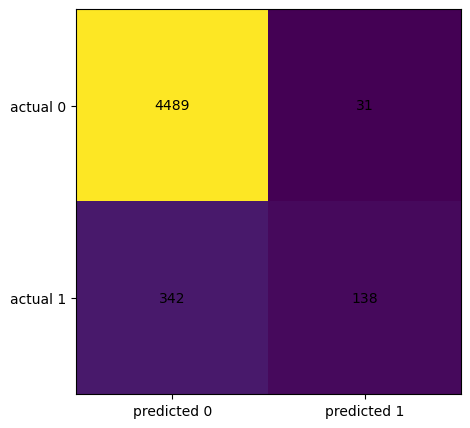

In [23]:
cm=confusion_matrix(y,clf.predict(x))

fig,ax=plt.subplots(figsize=(5,5))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1),ticklabels=("predicted 0","predicted 1"))
ax.yaxis.set(ticks=(0,1),ticklabels=("actual 0","actual 1"))
ax.set_ylim(1.5,-0.5)
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha="center",va="center",color="black")
    
plt.show()

In [24]:
TP=cm[0,0]
TN=cm[1,1]
FP=cm[0,1]
FN=cm[1,0]

In [25]:
classification_error=(FP+FN)/float(TP+TN+FP+FN)
print("classification_error :{0:0.4f}".format(classification_error))

classification_error :0.0746


In [26]:
x1=df1.iloc[:,:20].values
y=df1["Personal Loan"].values.reshape(-1,1)

In [27]:
p1={"Age":42,"Income":30,"ZIP Code":92037,"Family":3,"CCAvg":1.2 ,"Education":3 ,"Mortgage":0,"Personal Loan":0 ,"Securities Account":1,"CD Account": 0 ,"Online":1,"CreditCard":1}
df_test = pd.DataFrame([p1])

   
df_test["incom2"]=df_test["Income"]**2             
df_test["ccavg2"]=df_test["Income"]**2              
df_test["Mortgage2"]=df_test["Mortgage"]**2          
df_test["Education2"]= df_test["Education"]**2         
df_test["incom_edu"]= df_test["Income"]*df_test["Education"]                    
df_test["incom_ccav"]=df_test["Income"]*df_test["CCAvg"]        
df_test["inco_mort"]=df_test["Income"]*df_test["Mortgage"]             
df_test["incom_famil"]=df_test["Income"]*df_test["Family"]         
df_test["inco_cd"]=df_test["Income"]*df_test["CD Account"]



In [28]:
df1.drop(columns="Experience",inplace=True)
df1

,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,...,CreditCard,incom2,ccavg2,Mortgage2,Education2,incom_edu,incom_ccav,inco_mort,incom_famil,inco_cd
0,25,49,91107,4,1.6,1,0,0,1,0,...,0,2401,2.56,0,1,49,78.4,0,196,0
1,45,34,90089,3,1.5,1,0,0,1,0,...,0,1156,2.25,0,1,34,51.0,0,102,0
2,39,11,94720,1,1.0,1,0,0,0,0,...,0,121,1.00,0,1,11,11.0,0,11,0
3,35,100,94112,1,2.7,2,0,0,0,0,...,0,10000,7.29,0,4,200,270.0,0,100,0
4,35,45,91330,4,1.0,2,0,0,0,0,...,1,2025,1.00,0,4,90,45.0,0,180,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,40,92697,1,1.9,3,0,0,0,0,...,0,1600,3.61,0,9,120,76.0,0,40,0
4996,30,15,92037,4,0.4,1,85,0,0,0,...,0,225,0.16,7225,1,15,6.0,1275,60,0
4997,63,24,93023,2,0.3,3,0,0,0,0,...,0,576,0.09,0,9,72,7.2,0,48,0
4998,65,49,90034,3,0.5,2,0,0,0,0,...,0,2401,0.25,0,4,98,24.5,0,147,0


In [29]:
df2 = df1.append([df_test],ignore_index=True)
df2

C:\Users\Raya_Bit\AppData\Local\Temp\ipykernel_8460\4015298088.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df2 = df1.append([df_test],ignore_index=True)


,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,...,CreditCard,incom2,ccavg2,Mortgage2,Education2,incom_edu,incom_ccav,inco_mort,incom_famil,inco_cd
0,25,49,91107,4,1.6,1,0,0,1,0,...,0,2401,2.56,0,1,49,78.4,0,196,0
1,45,34,90089,3,1.5,1,0,0,1,0,...,0,1156,2.25,0,1,34,51.0,0,102,0
2,39,11,94720,1,1.0,1,0,0,0,0,...,0,121,1.00,0,1,11,11.0,0,11,0
3,35,100,94112,1,2.7,2,0,0,0,0,...,0,10000,7.29,0,4,200,270.0,0,100,0
4,35,45,91330,4,1.0,2,0,0,0,0,...,1,2025,1.00,0,4,90,45.0,0,180,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,30,15,92037,4,0.4,1,85,0,0,0,...,0,225,0.16,7225,1,15,6.0,1275,60,0
4997,63,24,93023,2,0.3,3,0,0,0,0,...,0,576,0.09,0,9,72,7.2,0,48,0
4998,65,49,90034,3,0.5,2,0,0,0,0,...,0,2401,0.25,0,4,98,24.5,0,147,0
4999,28,83,92612,3,0.8,1,0,0,0,0,...,1,6889,0.64,0,1,83,66.4,0,249,0


In [30]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
Nt = scaler.fit_transform(df2.iloc[:,[0,1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20]])
df_test1 = pd.DataFrame(Nt,columns = ["Age","Income","ZIP Code","Family","CCAvg","Education" ,
                                      "Mortgage" ,"Securities Account","CD Account","Online","CreditCard","incom2","ccavg2","Mortgage2","Education2",
                                      "incom_edu","incom_ccav","inco_mort","incom_famil","inco_cd"])
df_test1["Personal Loan"]=df2["Personal Loan"]
df_test1.head(5)


,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,...,incom2,ccavg2,Mortgage2,Education2,incom_edu,incom_ccav,inco_mort,incom_famil,inco_cd,Personal Loan
0,0.045455,0.189815,0.936527,1.000000,0.16,0.0,0.0,1.0,0.0,0.0,...,0.046636,0.002844,0.0,0.000,0.068220,0.038621,0.0,0.243523,0.0,0
1,0.500000,0.120370,0.924872,0.666667,0.15,0.0,0.0,1.0,0.0,0.0,...,0.021791,0.002500,0.0,0.000,0.043261,0.025123,0.0,0.121762,0.0,0
2,0.363636,0.013889,0.977892,0.000000,0.10,0.0,0.0,0.0,0.0,0.0,...,0.001137,0.001111,0.0,0.000,0.004992,0.005419,0.0,0.003886,0.0,0
3,0.272727,0.425926,0.970931,0.000000,0.27,0.5,0.0,0.0,0.0,0.0,...,0.198276,0.008100,0.0,0.375,0.319468,0.133005,0.0,0.119171,0.0,0
4,0.272727,0.171296,0.939080,1.000000,0.10,0.5,0.0,0.0,0.0,0.0,...,0.039132,0.001111,0.0,0.375,0.136439,0.022167,0.0,0.222798,0.0,0


In [31]:
df_test1

,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,...,incom2,ccavg2,Mortgage2,Education2,incom_edu,incom_ccav,inco_mort,incom_famil,inco_cd,Personal Loan
0,0.045455,0.189815,0.936527,1.000000,0.16,0.0,0.000000,1.0,0.0,0.0,...,0.046636,0.002844,0.000000,0.000,0.068220,0.038621,0.000000,0.243523,0.0,0
1,0.500000,0.120370,0.924872,0.666667,0.15,0.0,0.000000,1.0,0.0,0.0,...,0.021791,0.002500,0.000000,0.000,0.043261,0.025123,0.000000,0.121762,0.0,0
2,0.363636,0.013889,0.977892,0.000000,0.10,0.0,0.000000,0.0,0.0,0.0,...,0.001137,0.001111,0.000000,0.000,0.004992,0.005419,0.000000,0.003886,0.0,0
3,0.272727,0.425926,0.970931,0.000000,0.27,0.5,0.000000,0.0,0.0,0.0,...,0.198276,0.008100,0.000000,0.375,0.319468,0.133005,0.000000,0.119171,0.0,0
4,0.272727,0.171296,0.939080,1.000000,0.10,0.5,0.000000,0.0,0.0,0.0,...,0.039132,0.001111,0.000000,0.375,0.136439,0.022167,0.000000,0.222798,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,0.159091,0.032407,0.947174,1.000000,0.04,0.0,0.133858,0.0,0.0,1.0,...,0.003213,0.000178,0.017918,0.000,0.011647,0.002956,0.010297,0.067358,0.0,0
4997,0.909091,0.074074,0.958463,0.333333,0.03,1.0,0.000000,0.0,0.0,0.0,...,0.010217,0.000100,0.000000,1.000,0.106489,0.003547,0.000000,0.051813,0.0,0
4998,0.954545,0.189815,0.924242,0.666667,0.05,0.5,0.000000,0.0,0.0,1.0,...,0.046636,0.000278,0.000000,0.375,0.149750,0.012069,0.000000,0.180052,0.0,0
4999,0.113636,0.347222,0.953758,0.666667,0.08,0.0,0.000000,0.0,0.0,1.0,...,0.136195,0.000711,0.000000,0.000,0.124792,0.032709,0.000000,0.312176,0.0,0


In [32]:
x=df2.drop(["Personal Loan"],axis=1)[:5000]
y=df2[["Personal Loan"]][:5000].values.reshape(-1,1)
x_finall=df2.drop(["Personal Loan"],axis=1)[5000:]

In [33]:
clf.fit(x,y)
y_pred=clf.predict(x_finall)

C:\Users\Raya_Bit\anaconda4\envs\new\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [34]:
y_pred

array([0], dtype=int64)